In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os


In [ ]:
import os
# classification for RESNET-18 model
# -------------------------------
# PATHS (CHANGE IF NEEDED)
# -------------------------------
no_fire_image_folder = r"D:\projects\zeex-fire-detect\src\raw\archive (1)\fire_dataset\non_fire_images"
yolo_label_folder    = r"D:\projects\zeex-fire-detect\data\backup_dataset\nofirelabels"

# Create label folder if not exists
os.makedirs(yolo_label_folder, exist_ok=True)

# Supported image extensions
image_exts = (".jpg", ".jpeg", ".png")

count = 0

for img_name in os.listdir(no_fire_image_folder):
    if img_name.lower().endswith(image_exts):

        # Replace image extension with .txt
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(yolo_label_folder, label_name)

        # Create empty label file
        open(label_path, "w").close()
        count += 1

print(f"✅ Created {count} empty YOLO label files for NO-FIRE images")


✅ Created 1880 empty YOLO label files for NO-FIRE images


In [6]:
train_dir = r"D:\projects\zeex-fire-detect\data\processed\classification\train"
val_dir = r"D:\projects\zeex-fire-detect\data\processed\classification\valid"
test_dir = r"D:\projects\zeex-fire-detect\data\processed\classification\test"

batch_size = 32
lr = 0.0001
num_epochs = 10
num_classes = 3    # fire, smoke, null
device = "cuda" if torch.cuda.is_available() else "cpu"


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [8]:
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data = datasets.ImageFolder(val_dir, transform=test_transform)
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

class_names = train_data.classes
print("Classes:", class_names)


Classes: ['fire', 'null', 'smoke']


In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace last FC layer for 3 classes
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


In [11]:
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    accuracy = correct / len(val_data)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {accuracy:.4f}")


Epoch 1/10 | Train Loss: 0.2173 | Val Loss: 0.0247 | Val Acc: 0.9917
Epoch 2/10 | Train Loss: 0.0877 | Val Loss: 0.0276 | Val Acc: 0.9950
Epoch 3/10 | Train Loss: 0.0714 | Val Loss: 0.1558 | Val Acc: 0.9250
Epoch 4/10 | Train Loss: 0.0597 | Val Loss: 0.0103 | Val Acc: 1.0000
Epoch 5/10 | Train Loss: 0.0481 | Val Loss: 0.0202 | Val Acc: 0.9933
Epoch 6/10 | Train Loss: 0.0454 | Val Loss: 0.0185 | Val Acc: 0.9917
Epoch 7/10 | Train Loss: 0.0315 | Val Loss: 0.0088 | Val Acc: 0.9967
Epoch 8/10 | Train Loss: 0.0229 | Val Loss: 0.0014 | Val Acc: 1.0000
Epoch 9/10 | Train Loss: 0.0251 | Val Loss: 0.0008 | Val Acc: 1.0000
Epoch 10/10 | Train Loss: 0.0168 | Val Loss: 0.0029 | Val Acc: 1.0000


In [12]:
torch.save(model.state_dict(), "resnet18_fire_smoke_null.pth")
print("Model saved.")


Model saved.


In [13]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        output = model(images)
        _, predicted = torch.max(output, 1)

        y_true.append(labels.item())
        y_pred.append(predicted.item())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report:
              precision    recall  f1-score   support

        fire       0.85      1.00      0.92        40
        null       1.00      1.00      1.00        40
       smoke       1.00      0.82      0.90        40

    accuracy                           0.94       120
   macro avg       0.95      0.94      0.94       120
weighted avg       0.95      0.94      0.94       120



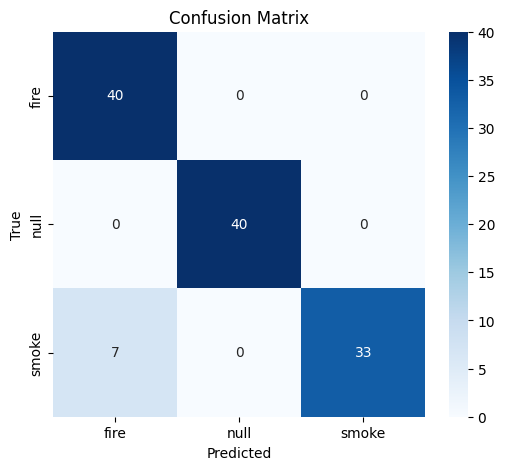

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


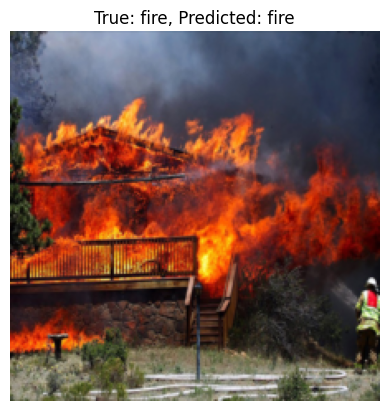

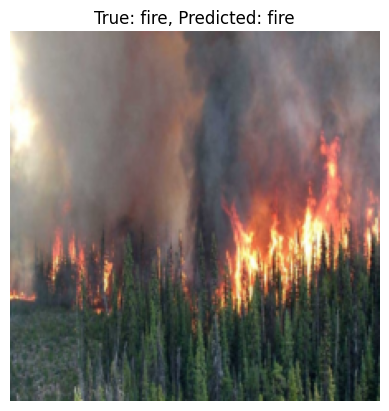

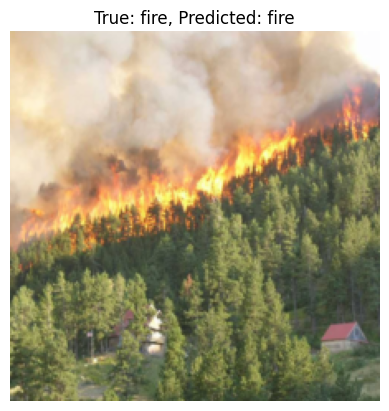

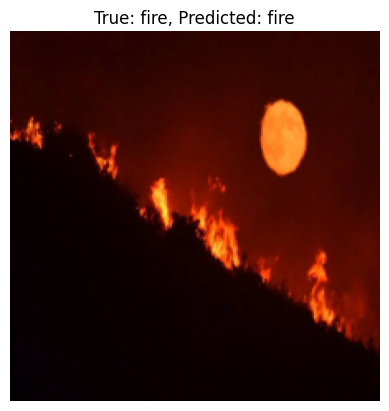

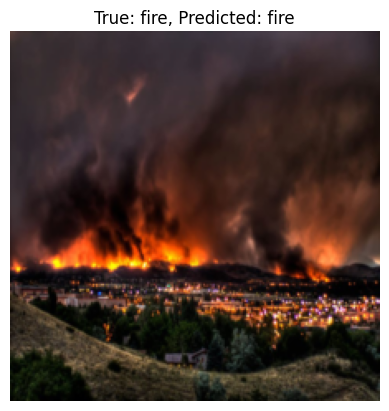

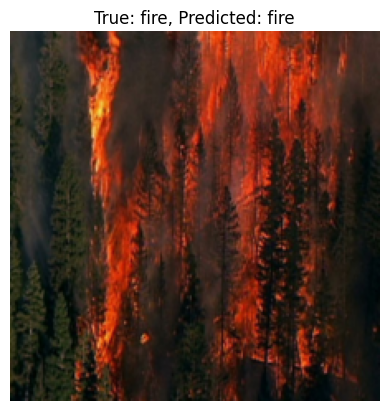

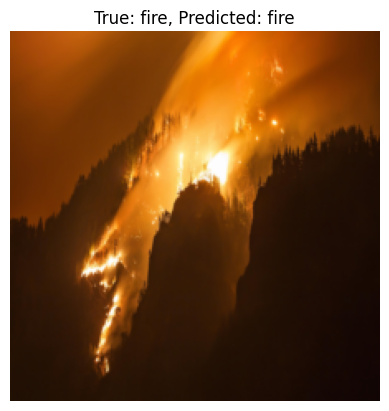

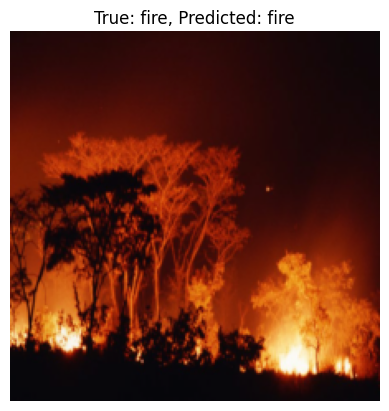

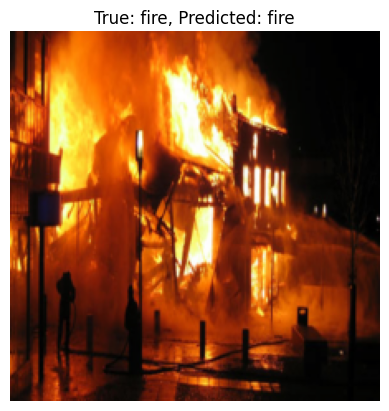

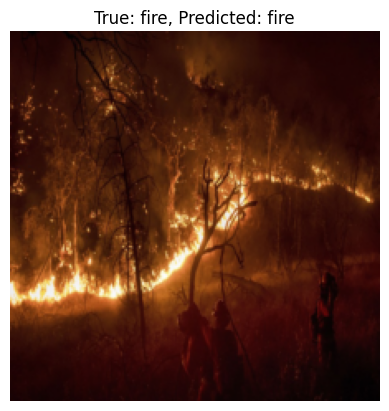

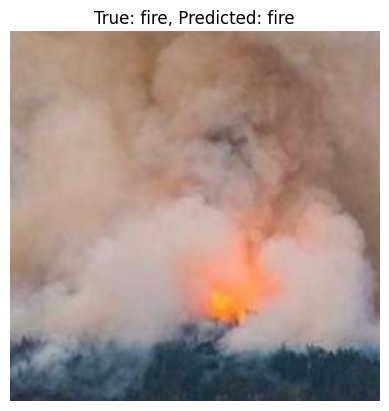

In [15]:
def imshow(img_tensor, title):
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))

    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


model.eval()

for i, (img, label) in enumerate(test_loader):
    img = img.to(device)
    output = model(img)
    _, predicted = torch.max(output, 1)

    title = f"True: {class_names[label.item()]}, Predicted: {class_names[predicted.item()]}"
    imshow(img[0], title)

    if i == 10:  # show 10 images
        break


In [16]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
import os


In [17]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [18]:
def load_single_class(test_root, class_name):
    folder_path = os.path.join(test_root, class_name)
    dataset = datasets.ImageFolder(test_root, transform=test_transform)

    # Filtering dataset indices belonging only to this class
    class_idx = dataset.class_to_idx[class_name]
    indices = [i for i, (_, label) in enumerate(dataset.samples) if label == class_idx]

    # Subset for only this class
    subset = torch.utils.data.Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=1, shuffle=True)

    return loader, dataset.classes


In [19]:
def imshow(img_tensor, title):
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


In [20]:
test_root = r"D:\projects\zeex-fire-detect\data\processed\classification\test" 
# Example: D:/projects/fire_classifier/test


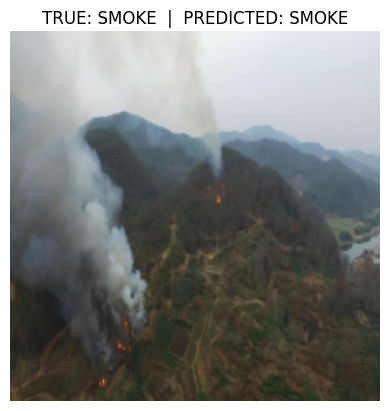

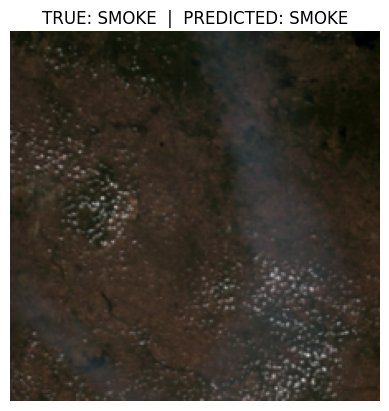

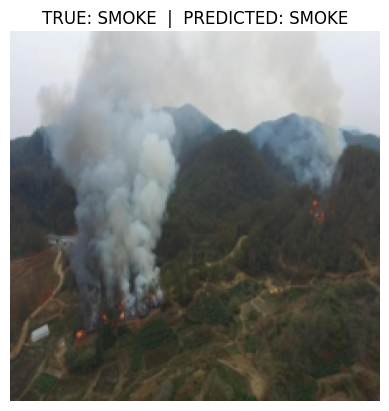

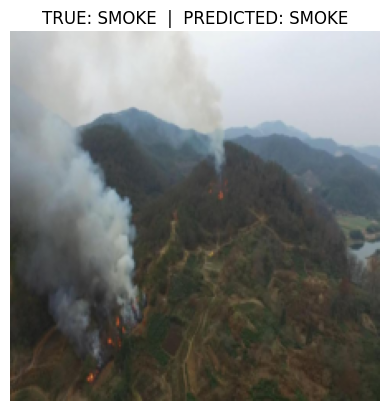

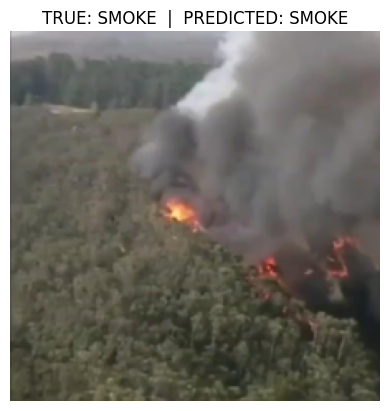

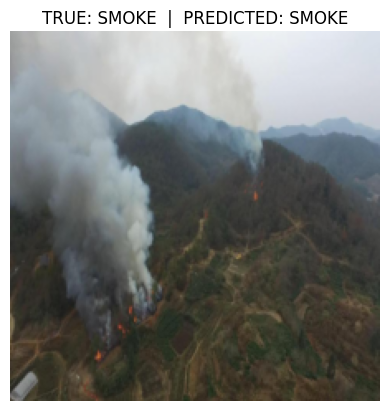

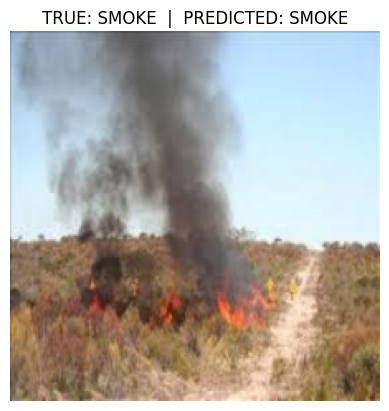

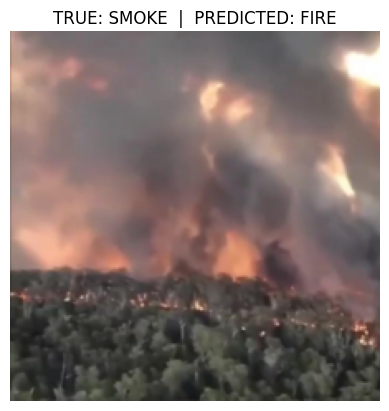

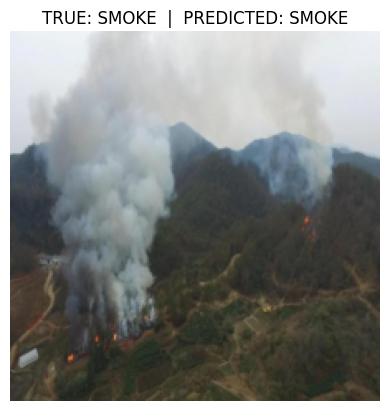

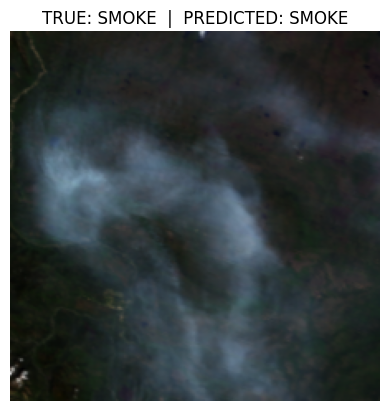

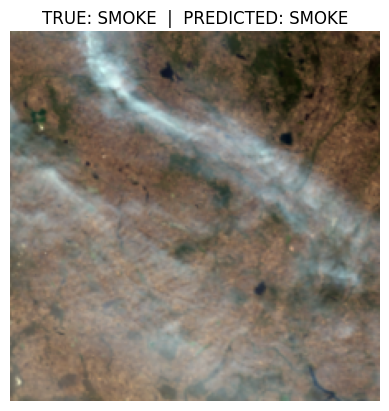

In [21]:
model.eval()
class_name = "smoke"   # change to 'smoke' or 'null'

loader, class_names = load_single_class(test_root, class_name)

for i, (img, label) in enumerate(loader):
    img = img.to(device)
    output = model(img)
    _, predicted = torch.max(output, 1)

    true_label = class_names[label.item()]
    pred_label = class_names[predicted.item()]

    title = f"TRUE: {true_label.upper()}  |  PREDICTED: {pred_label.upper()}"
    imshow(img[0], title)

    if i == 10:
        break


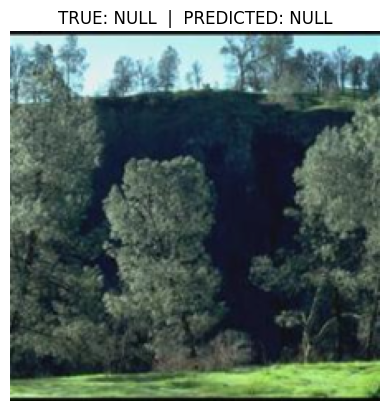

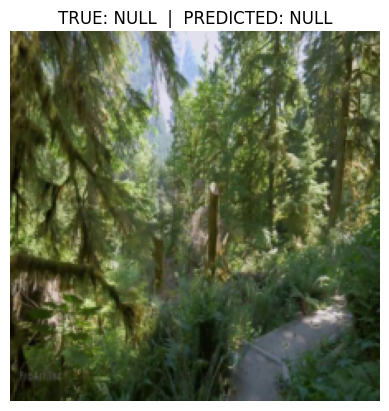

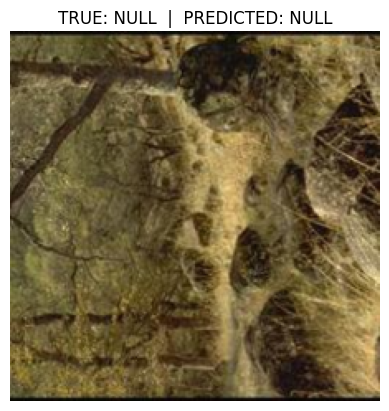

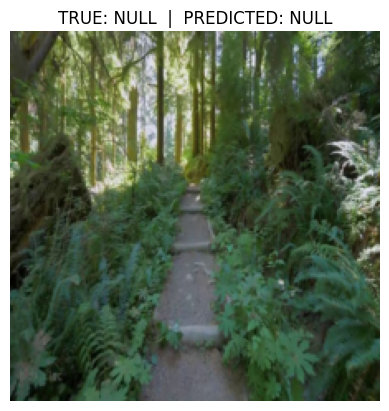

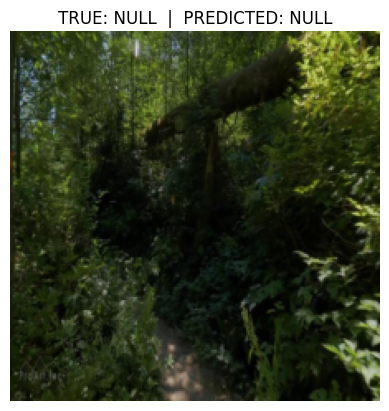

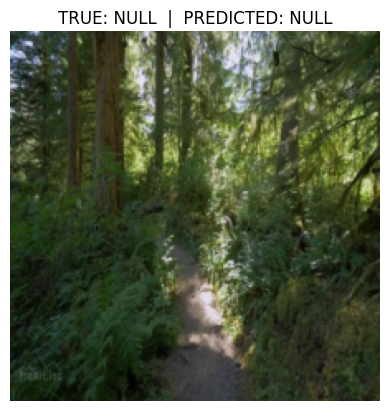

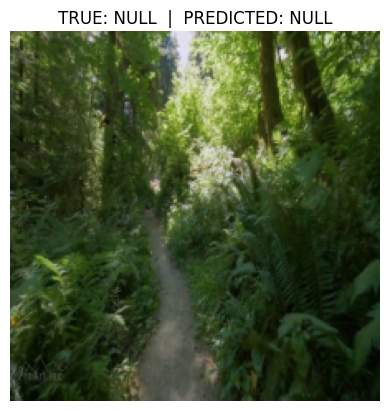

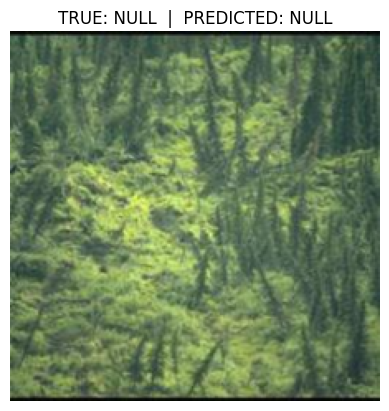

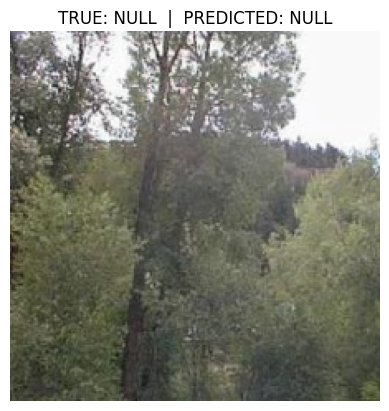

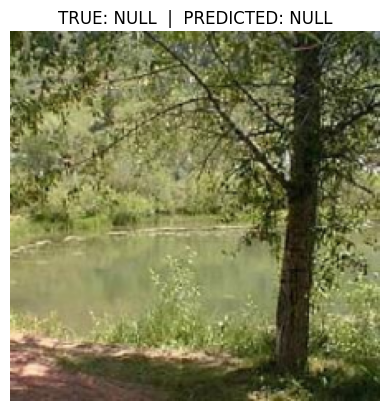

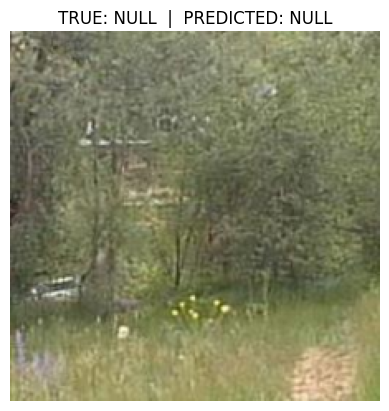

In [22]:
model.eval()
class_name = "null"   # change to 'smoke' or 'null'

loader, class_names = load_single_class(test_root, class_name)

for i, (img, label) in enumerate(loader):
    img = img.to(device)
    output = model(img)
    _, predicted = torch.max(output, 1)

    true_label = class_names[label.item()]
    pred_label = class_names[predicted.item()]

    title = f"TRUE: {true_label.upper()}  |  PREDICTED: {pred_label.upper()}"
    imshow(img[0], title)

    if i == 10:
        break


In [23]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [24]:
def show_image(img_tensor, title):
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


In [3]:
def predict_image(image_path, model, class_names):
    model.eval()

    img = Image.open(image_path).convert("RGB")
    img_t = transform(img)
    input_tensor = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        predicted_class = class_names[pred.item()]

    show_image(img_t, f"Predicted: {predicted_class}")
    return predicted_class


In [7]:
%pip install ultralytics


Note: you may need to restart the kernel to use updated packages.


In [8]:
from ultralytics import YOLO

# Load a pretrained Nano model (best for small dataset)
model = YOLO("yolov8n.pt")


In [1]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


In [3]:
tf.debugging.set_log_device_placement(True)


In [9]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# -------------------------------
# 1. Load your trained model
# -------------------------------
model = load_model(r"D:\projects\zeex-fire-detect\best_fire_smoke_model.h5")

# -------------------------------
# 2. Define class labels (must match your training generator)
# -------------------------------
class_labels = ['fire', 'null', 'smoke']  # order should match train_gen.class_indices

# -------------------------------
# 3. Load and preprocess the image
# -------------------------------
img_path = r"D:\projects\zeex-fire-detect\data\processed\classification\test\smoke\Smoke (132).jpg"

# Load image with target size same as training
img = image.load_img(img_path, target_size=(128, 128))

# Convert to array
img_array = image.img_to_array(img)

# Rescale to [0,1]
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# -------------------------------
# 4. Make prediction
# -------------------------------
pred_prob = model.predict(img_array)          # Returns probabilities
pred_class = np.argmax(pred_prob, axis=1)     # Index of highest probability

# -------------------------------
# 5. Output results
# -------------------------------
print("Predicted class:", class_labels[pred_class[0]])
print("Probabilities:", pred_prob[0])


Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing o

In [ ]:
#complete code save model for classification using CNN
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# -------------------------------
# 1. CONFIGURATION
# -------------------------------
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 25

TRAIN_DIR = r"D:\projects\zeex-fire-detect\data\processed\classification\train"
TEST_DIR = r"D:\projects\zeex-fire-detect\data\processed\classification\test"
MODEL_PATH = r"D:\projects\zeex-fire-detect\best_fire_smoke_model.h5"

CLASS_LABELS = ['fire', 'null', 'smoke']  # must match train generator order

# -------------------------------
# 2. DATA AUGMENTATION
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.25,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.25,
    brightness_range=[0.4, 1.6],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(rescale=1./255)

# -------------------------------
# 3. LOAD DATA
# -------------------------------
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# -------------------------------
# 4. COMPUTE CLASS WEIGHTS
# -------------------------------
# This helps improve detection for underrepresented classes
classes = list(train_gen.class_indices.keys())
y_train = train_gen.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# -------------------------------
# 5. BUILD CNN MODEL
# -------------------------------
model = Sequential([

    # BLOCK 1
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),
    Dropout(0.25),

    # BLOCK 2
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),
    Dropout(0.30),

    # BLOCK 3
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3,3), activation="relu", padding="same"),
    MaxPooling2D(),
    Dropout(0.40),

    Flatten(),

    # FC Layers
    Dense(256, activation="relu"),
    Dropout(0.50),
    Dense(len(CLASS_LABELS), activation="softmax")
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# -------------------------------
# 6. CHECKPOINT TO SAVE BEST MODEL
# -------------------------------
checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# -------------------------------
# 7. TRAIN MODEL
# -------------------------------
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[checkpoint]
)

# -------------------------------
# 8. LOAD BEST MODEL
# -------------------------------
model = load_model(MODEL_PATH)
print(f"\nBest model loaded from: {MODEL_PATH}")

# -------------------------------
# 9. TEST SINGLE OR MULTIPLE IMAGES
# -------------------------------
def predict_and_display(folder_path):
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        if not img_file.lower().endswith(('.png','.jpg','.jpeg')):
            continue

        # Load and preprocess
        img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = image.img_to_array(img)/255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Prediction
        pred_prob = model.predict(img_array)
        pred_class = np.argmax(pred_prob, axis=1)[0]
        pred_label = CLASS_LABELS[pred_class]

        # Display image with prediction
        img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
        cv2.putText(img_cv, f"Pred: {pred_label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
        cv2.imshow("Prediction", img_cv)
        cv2.waitKey(0)  # press any key to move to next image
        cv2.destroyAllWindows()

        # Print probabilities
        print(f"{img_file} -> Predicted: {pred_label}, Probabilities: {pred_prob[0]}")

# -------------------------------
# Example usage
# -------------------------------
test_image_folder = r"D:\projects\zeex-fire-detect\data\processed\classification\test\smoke"
predict_and_display(test_image_folder)


Found 2630 images belonging to 3 classes.
Found 120 images belonging to 3 classes.
Class weights: {0: 0.7897897897897898, 1: 1.3697916666666667, 2: 0.9962121212121212}
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/

In [ ]:
# classification from scratch
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import cv2

# -------------------------------
# 1. Load trained model
# -------------------------------
model = load_model(r"D:\projects\zeex-fire-detect\best_fire_smoke_model.h5")

# -------------------------------
# 2. Class labels
# -------------------------------
class_labels = ['fire', 'null', 'smoke']

# -------------------------------
# 3. INPUT IMAGE PATH
# -------------------------------
img_path = r"D:\projects\zeex-fire-detect\data\processed\classification\test\null\nf2 (380).jpg"  # your test image

# -------------------------------
# 4. Load + preprocess image
# -------------------------------
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# -------------------------------
# 5. Predict
# -------------------------------
pred_prob = model.predict(img_array, verbose=0)
pred_class = np.argmax(pred_prob)
confidence = pred_prob[0][pred_class] * 100

print(f"Predicted: {class_labels[pred_class]}, Confidence: {confidence:.2f}%")

# -------------------------------
# 6. Show image with predicted text
# -------------------------------
img_cv = cv2.imread(img_path)
cv2.putText(img_cv,
            f"{class_labels[pred_class]} ({confidence:.1f}%)",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2)

cv2.imshow("Prediction Output", img_cv)
cv2.waitKey(0)
cv2.destroyAllWindows()


Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op _EagerConst in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomGetKeyCounter in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op StatelessRandomUniformV2 in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing o